<a href="https://colab.research.google.com/github/EstephanyReyes/procesos-estocasticos/blob/main/Descomposici%C3%B3n_can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Descomposición canónica
#1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.
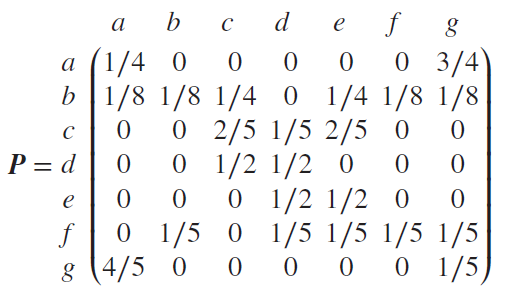

In [62]:
import numpy as np
import networkx as nx
from math import gcd
from functools import reduce

states = ['a','b','c','d','e','f','g']

P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])
print (P)

[[0.25  0.    0.    0.    0.    0.    0.75 ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]
 [0.8   0.    0.    0.    0.    0.    0.2  ]]


#2. Determine si la matriz tiene o no distribución límite.

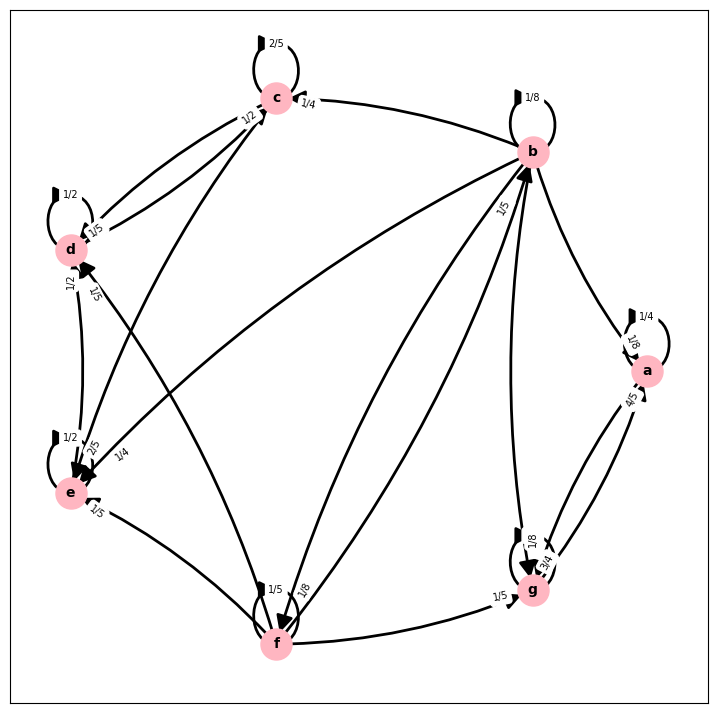

In [63]:
#diagrama de transición
G = nx.DiGraph()

def frac(x):
    return str(Fraction(x).limit_denominator())

# aristas
for i in range(len(states)):
    for j in range(len(states)):
        if P[i, j] > 0:
            G.add_edge(states[i], states[j], weight=frac(P[i, j]))

# posiciones
n = len(states)
angle = 2 * np.pi / n
pos = {}
for k, state in enumerate(states):
    theta = k * angle
    pos[state] = (np.cos(theta), np.sin(theta))

plt.figure(figsize=(9,9))

# nodos
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightpink')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=25,
    width=2,
    connectionstyle='arc3,rad=0.1'
)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=7,
    label_pos=0.9
)

plt.show()

In [64]:
#identificar clases de comunicación
scc = list(nx.strongly_connected_components(G))
print("Clases:", scc)

Clases: [{'a', 'g'}, {'e', 'c', 'd'}, {'b', 'f'}]


In [65]:
#clasificación de estados (recurrentes y transitorios)
closed_classes = []
transient = []

for comp in scc:
    is_closed = True
    for s in comp:
        i = states.index(s)
        for j in range(len(states)):
            if P[i,j] > 0 and states[j] not in comp:
                is_closed = False
    if is_closed:
        closed_classes.append(comp)
    else:
        transient.extend(comp)

print("Clases recurrentes (cerradas):", closed_classes)
print("Estados transitorios:", transient)

Clases recurrentes (cerradas): [{'a', 'g'}, {'e', 'c', 'd'}]
Estados transitorios: ['b', 'f']


In [66]:
#función para calcular el periodo por clase
def period_of_class(G, comp):
    lengths = []
    for node in comp:
        for cycle in nx.simple_cycles(G): #ciclos del grafo
            if node in cycle:     #guarda la longitud
                lengths.append(len(cycle))
    if lengths:
        return reduce(gcd, lengths)
    return 1

In [67]:
#periodo para clase recurrentes
for comp in closed_classes:
    d = period_of_class(G, comp)
    print(f"Clase {comp} tiene período {d}")

Clase {'a', 'g'} tiene período 1
Clase {'e', 'c', 'd'} tiene período 1


In [68]:
aperiodic = all(period_of_class(G, comp) == 1 for comp in closed_classes)

if aperiodic:
    print("La cadena SÍ tiene distribución límite.")
else:
    print("La cadena NO tiene distribución límite.")

La cadena SÍ tiene distribución límite.


#3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.



In [69]:
import numpy as np
import networkx as nx
from fractions import Fraction

# matriz y estados originales
states = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

# identificar tipos de estados y clases cerradas
G = nx.from_numpy_array(P, create_using=nx.DiGraph)
clases_scc = list(nx.strongly_connected_components(G))

recurrentes_por_clase = []
transitorios = []

for clase in clases_scc:
    es_cerrada = all(all(v in clase for v in G.neighbors(n)) for n in clase)
    if es_cerrada:
        recurrentes_por_clase.append(sorted(list(clase)))
    else:
        transitorios.extend(list(clase))

transitorios.sort()
recurrentes_todos = [idx for clase in recurrentes_por_clase for idx in clase]
nuevo_orden = transitorios + recurrentes_todos
nombres_ordenados = [states[i] for i in nuevo_orden]

# matriz Canónica
P_canonica = P[np.ix_(nuevo_orden, nuevo_orden)]
print("Nuevo orden de estados:", nombres_ordenados)

# determinar el límite de P^n
n_potencia = 100
Pn = np.linalg.matrix_power(P_canonica, n_potencia)
print(f"\n Límite de P^{n_potencia} (Aproximación numérica)")
print(np.round(Pn, 4))

# distribuciones límite de las submatrices recurrentes
def calcular_pi(submatriz):
    n = submatriz.shape[0]
    A = submatriz.T - np.eye(n)
    A[-1] = np.ones(n)
    b = np.zeros(n)
    b[-1] = 1
    return np.linalg.solve(A, b)

print("\n Comparación: Distribuciones Estacionarias contra Filas de P^n")
inicio = len(transitorios)
for clase in recurrentes_por_clase:
    fin = inicio + len(clase)
    R_sub = P_canonica[inicio:fin, inicio:fin]
    pi = calcular_pi(R_sub)

    nombres_clase = [states[i] for i in clase]
    print(f"\nClase Recurrente {nombres_clase}:")
    print(f"  π analítico: {np.round(pi, 4)}")
    print(f"  Fila de P^n: {np.round(Pn[inicio, inicio:fin], 4)}")
    inicio = fin


Nuevo orden de estados: ['B', 'F', 'A', 'G', 'C', 'D', 'E']

 Límite de P^100 (Aproximación numérica)
[[0.     0.     0.172  0.1613 0.2222 0.2667 0.1778]
 [0.     0.     0.172  0.1613 0.2222 0.2667 0.1778]
 [0.     0.     0.5161 0.4839 0.     0.     0.    ]
 [0.     0.     0.5161 0.4839 0.     0.     0.    ]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]]

 Comparación: Distribuciones Estacionarias contra Filas de P^n

Clase Recurrente ['A', 'G']:
  π analítico: [0.5161 0.4839]
  Fila de P^n: [0.5161 0.4839]

Clase Recurrente ['C', 'D', 'E']:
  π analítico: [0.3333 0.4    0.2667]
  Fila de P^n: [0.3333 0.4    0.2667]


#4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.

In [70]:
import numpy as np
import networkx as nx
from fractions import Fraction

# matriz y estados originales
states = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4], # A
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8], # B
    [0,   0,   2/5, 1/5, 2/5, 0,   0],   # C
    [0,   0,   1/2, 1/2, 0,   0,   0],   # D
    [0,   0,   0,   1/2, 1/2, 0,   0],   # E
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5], # F
    [4/5, 0,   0,   0,   0,   0,   1/5]  # G
])

# identificar tipos de estados
G = nx.from_numpy_array(P, create_using=nx.DiGraph)
clases = list(nx.strongly_connected_components(G))

recurrentes = []
transitorios = []

for clase in clases:
    es_cerrada = all(all(vecino in clase for vecino in G.neighbors(n)) for n in clase)
    if es_cerrada:
        recurrentes.extend(list(clase))
    else:
        transitorios.extend(list(clase))

# orden nuevo, transitorios - recurrentes
nuevo_orden = transitorios + recurrentes
nombres_ordenados = [states[i] for i in nuevo_orden]

#matriz Canónica
P_canonica = P[np.ix_(nuevo_orden, nuevo_orden)]

print("Nuevo orden de estados (Canónico):", nombres_ordenados)
print("\nMatriz en Forma Canónica")

for fila in P_canonica:
    print([str(Fraction(x).limit_denominator()) for x in fila])

Nuevo orden de estados (Canónico): ['B', 'F', 'A', 'G', 'C', 'D', 'E']

Matriz en Forma Canónica
['1/8', '1/8', '1/8', '1/8', '1/4', '0', '1/4']
['1/5', '1/5', '0', '1/5', '0', '1/5', '1/5']
['0', '0', '1/4', '3/4', '0', '0', '0']
['0', '0', '4/5', '1/5', '0', '0', '0']
['0', '0', '0', '0', '2/5', '1/5', '2/5']
['0', '0', '0', '0', '1/2', '1/2', '0']
['0', '0', '0', '0', '0', '1/2', '1/2']
